# BTC-Halving — a quantitative teardown
### Real BTC-USD tape · cycle-extrema scatter · phase-bucket HAC *t* · the three-cluster problem · timing vs buy-and-hold · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Prints_the_top_%26_bottom%3F: Busted](https://img.shields.io/badge/Prints_the_top_%26_bottom%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error (and its honest sample size).* We test whether the halving-locked cycle is statistically real, whether the halving marks the cycle extrema, and whether a calendar-timed rule beats buy-and-hold — and we name the central limit loudly: **Yahoo covers three halvings, so the effective *n* is three cycles.**

> **Not investment advice.** Real data: Yahoo `BTC-USD` daily, 2014-09-17 → 2026-06-14 (fingerprint `3c26b7c8e544`); the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc_halving import data, strategy as st

def _load_real():
    try:
        return data.load_real()
    except Exception as e:
        print("real cache unavailable -> using frozen numbers / synthetic:", e)
        return None

BARS = _load_real()
HAVE_REAL = BARS is not None
print("real BTC-USD cache present:", HAVE_REAL)
if HAVE_REAL:
    print("tape:", BARS.index[0].date(), "->", BARS.index[-1].date(),
          "fingerprint", data.fingerprint(BARS))


real BTC-USD cache present: True
tape: 2014-09-17 -> 2026-06-14 fingerprint 3c26b7c8e544


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Post-halving quarter +31.9 bps/day, naive HAC *t* +3.45 — but fed by **3** cycles (+36/+52/+8 bps/day, decaying). A daily *t* on three clusters overstates it. |
| **Tradability** | `MIRAGE` | Timing rule +35%/yr vs B&H +52%/yr; excess HAC *t* -0.92, bootstrap CI [-10.6, +4.2] bps/day. Underperforms holding. |
| **Prints the top & bottom?** | `BUSTED` | High offsets [1296, 525, 1402, 534] d; low offsets [777, 24, 0, 139] d — no cluster. |

> In plain words: a faint, fading post-halving drift measured on three cycles, an extrema pattern that doesn't exist, and a calendar timer that loses to buy-and-hold.

## 1 · The claim, steelmanned

Let $\phi_t \in [0,1)$ be the fractional phase within the 4-year halving cycle (0 at a halving). The lore makes four testable claims:

- **H₁ (cycle exists).** $\mathbb{E}[r_t \mid \phi_t]$ varies with phase — the post-halving phase pays more.
- **H₂ (the halving prints the top).** The cycle high clusters at $\phi \approx 0.25\text{–}0.4$ (~12-18 months after).
- **H₃ (the halving prints the bottom).** The cycle low clusters near $\phi \approx 0$ or $\phi \approx 1$.
- **H₄ (tradable).** A long-the-bull-half rule beats buy-and-hold net of costs.

We find **H₁ weakly supported but uncertifiable** (n = 3 cycles), **H₂ and H₃ rejected** (extrema scatter), and **H₄ rejected** (it loses to holding).

## 2 · So what? — what rides on each answer

A *scheduled* supply cut cannot be a tradable surprise — efficient markets price a known event in advance (Fama 1970) — so any post-halving drift must come from something other than the cut being news. Stock-to-flow tried to supply that mechanism and broke down out of sample, the classic spurious-regression of two trending series (Granger-Newbold 1974). The interesting content isn't the binary verdict; it's **how a three-cluster sample masquerades as a thousand independent days**, and how a calendar 'edge' on a single trending asset is just beta with a cash drag.

## 3 · How we'd know — the protocol

- **Extrema.** For each halving, the day-offset of the price high/low in the $[h, h+1458\text{d})$ window (`cycle_extrema`). Cluster → H₂/H₃; scatter → reject.
- **Phase buckets.** Mean daily log-return in each quarter of $\phi$, with a Newey-West HAC *t* (`phase_bucket_returns`) — **read against the cycle count.**
- **Per-cycle reveal.** The post-halving-quarter mean *per halving* — the honest unit of observation.
- **Timing race.** Long $\phi \in [0, 0.5)$ else flat; one-bar fill lag, one-way × NAV costs; excess-vs-buy-and-hold HAC *t* and block-bootstrap CI.
- **Positive control.** A deterministic GBM tape with a tunable halving-locked sinusoid — the harness must detect the planted cycle and find nothing in the null.

Tape: Yahoo `BTC-USD` daily, **2014-09-17 →** — covering 2016 (partial), 2020, 2024.

## 4 · The teardown

### 4a · Do the extrema cluster? (H₂, H₃)

Day-offset of each cycle's high and low, relative to the halving.

   halving  n_days_in_window  high_offset_d  low_offset_d  high_ret_x  low_ret_x
2012-11-28              1457           1296           777    1.675598   0.389437
2016-07-09              1457            525            24   29.951763   0.841012
2020-05-11              1457           1402             0    8.496307   1.000000
2024-04-20               785            534           139    1.919434   0.830052


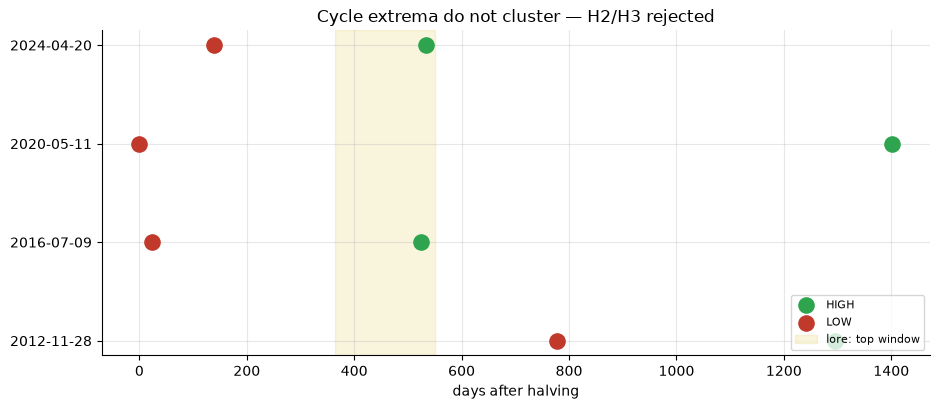

In [2]:
if HAVE_REAL:
    ext = st.cycle_extrema(BARS)
    print(ext.to_string(index=False))
    hi = ext['high_offset_d'].tolist(); lo = ext['low_offset_d'].tolist()
    labs = [str(h.date()) for h in ext['halving']]
else:
    hi = [1296, 525, 1402, 534]; lo = [777, 24, 0, 139]
    labs = ['2012-11','2016-07','2020-05','2024-04']
fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(labs))
ax.scatter(hi, x, s=120, color=GREEN, label='HIGH', zorder=3)
ax.scatter(lo, x, s=120, color=RED, label='LOW', zorder=3)
ax.axvspan(365, 550, color=AMBER, alpha=.15, label='lore: top window')
ax.set_yticks(x); ax.set_yticklabels(labs); ax.set_xlabel('days after halving')
ax.set_title('Cycle extrema do not cluster — H2/H3 rejected')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

> 💡 In plain words: highs at [1296, 525, 1402, 534] days, lows at [777, 24, 0, 139] days. No cluster — the halving marks neither the top nor the bottom. **H₂, H₃ rejected.**

### 4b · The phase-bucket drift and the three-cluster trap (H₁)

Mean daily return by cycle quarter, with the *naive* daily HAC *t* — then the honest per-cycle view that deflates it.

 bucket  phase_lo  phase_hi    n  mean_bps  tstat
      0      0.00      0.25 1095    31.873  3.454
      1      0.25      0.50 1162     0.314  0.026
      2      0.50      0.75 1152     1.861  0.182
      3      0.75      1.00  879    13.706  1.225


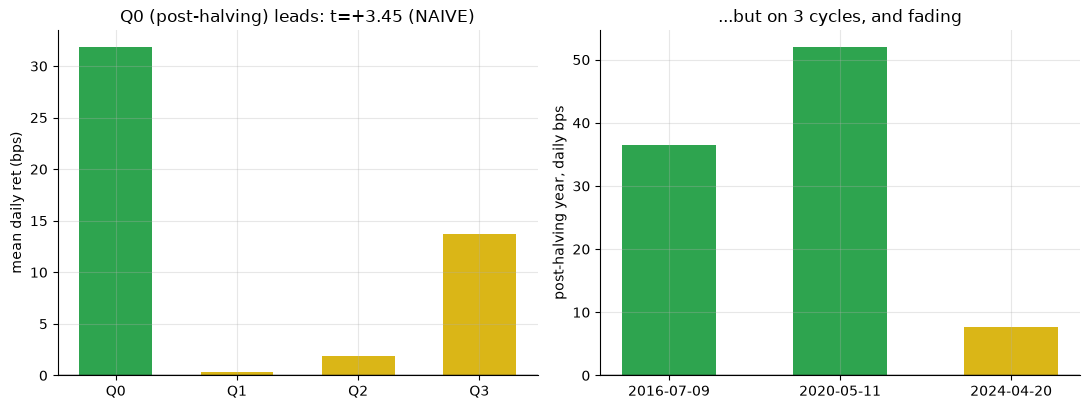

per-cycle post-halving daily bps: [np.float64(36.5), np.float64(52.1), np.float64(7.7)]


In [3]:
if HAVE_REAL:
    pb = st.phase_bucket_returns(BARS, 4)
    print(pb.round(3).to_string(index=False))
    means = pb['mean_bps'].tolist(); ts = pb['tstat'].tolist()
    lr = np.log(BARS['close']).diff()
    per = []
    for h in data.HALVINGS:
        if not (BARS.index.min() <= h <= BARS.index.max()):
            continue
        seg = lr[(lr.index >= h) & (lr.index < h + pd.Timedelta(days=364))].dropna()
        per.append((str(h.date()), seg.mean()*1e4))
    per_labs = [p[0] for p in per]; per_vals = [p[1] for p in per]
else:
    means = [31.9, 0.3, 1.9, 13.7]
    ts = [3.45, 0.03, 0.18, 1.23]
    per_labs = ['2016-07','2020-05','2024-04']
    per_vals = [36.5, 52.1, 7.7]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
qcol = [GREEN if t >= 2 else AMBER for t in ts]
a1.bar([f'Q{i}' for i in range(len(means))], means, color=qcol, width=.6)
a1.axhline(0, c='k', lw=1); a1.set_ylabel('mean daily ret (bps)')
a1.set_title(f'Q0 (post-halving) leads: t={ts[0]:+.2f} (NAIVE)')
a2.bar(per_labs, per_vals, color=[GREEN if v>20 else AMBER for v in per_vals], width=.55)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('post-halving year, daily bps')
a2.set_title(f'...but on {len(per_vals)} cycles, and fading')
plt.tight_layout(); plt.show()
print('per-cycle post-halving daily bps:', [round(v,1) for v in per_vals])

> 💡 In plain words: the post-halving quarter's naive HAC *t* of +3.45 *looks* like it clears the bar — but it pools ~1000 autocorrelated days from **3 halvings** as if they were independent. The honest unit is the cycle, and the three cycles paid +36/+52/+8 bps/day — *decaying*, with the latest near zero. With three clusters no *t* is trustworthy (Cameron-Gelbach-Miller 2011). **H₁ weak, not real.**

### 4c · The timing race (H₄)

Long the bull half of each cycle vs buy-and-hold — the only honest benchmark for a single trending asset. Excess-vs-buy-and-hold with HAC *t* and bootstrap CI.

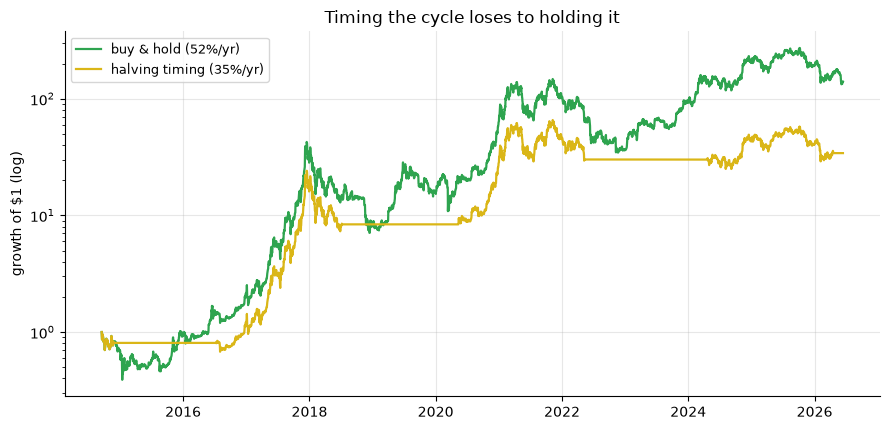

timing 35.1%/yr  vs  B&H 52.3%/yr   excess t=-0.92   CI[-10.5,+4.2] bps/day
time in market 53%, 8 flips


In [4]:
if HAVE_REAL:
    book = st.timing_rule(BARS, 0.0, 0.5, cost_bps=10.0)
    s = st.summarize_timing(book)
    lo, hi = st.block_bootstrap_ci(book['ret_strat'].to_numpy() - book['ret_bh'].to_numpy())
    cs, cb, et = s['cagr_strat']*100, s['cagr_bh']*100, s['excess_t']
    tim, fl = s['time_in_market']*100, s['n_flips']
    eqs, eqb = book['eq_strat'], book['eq_bh']
else:
    cs, cb, et = 35.1, 52.3, -0.92
    lo, hi = -10.6, 4.2; tim, fl = 52.6, 8
    eqs = eqb = None
fig, ax = plt.subplots(figsize=(9.0, 4.4))
if eqs is not None:
    ax.plot(eqb.index, eqb, c=GREEN, lw=1.6, label=f'buy & hold ({cb:.0f}%/yr)')
    ax.plot(eqs.index, eqs, c=AMBER, lw=1.6, label=f'halving timing ({cs:.0f}%/yr)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
else:
    ax.bar(['timing','buy & hold'], [cs, cb], color=[AMBER, GREEN], width=.5)
    ax.set_ylabel('annualised %/yr')
ax.set_title('Timing the cycle loses to holding it')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'timing {cs:.1f}%/yr  vs  B&H {cb:.1f}%/yr   excess t={et:+.2f}   CI[{lo:+.1f},{hi:+.1f}] bps/day')
print(f'time in market {tim:.0f}%, {fl} flips')

> 💡 In plain words: +35%/yr vs +52%/yr, excess HAC *t* -0.92, bootstrap CI [-10.6, +4.2] bps/day straddling zero (tilted negative). The timer sits in cash through part of the biggest up-leg and loses. **H₄ rejected.**

## 5 · The verdict

- **Signal `WEAK`** — post-halving quarter +31.9 bps/day (naive HAC *t* +3.45), but on 3 cycles (+36/+52/+8, fading). Literature-flavoured, uncertifiable on this tape.
- **Tradability `MIRAGE`** — timing +35%/yr vs B&H +52%/yr; excess *t* -0.92. Loses to holding.
- **Prints the top & bottom? `BUSTED`** — extrema at [1296, 525, 1402, 534] / [777, 24, 0, 139] days, no cluster.

## 6 · Could you trade it? — the cost sweep and the real wall

Costs are a sideshow (the rule flips a handful of times); the wall is the cash drag against a trending asset.

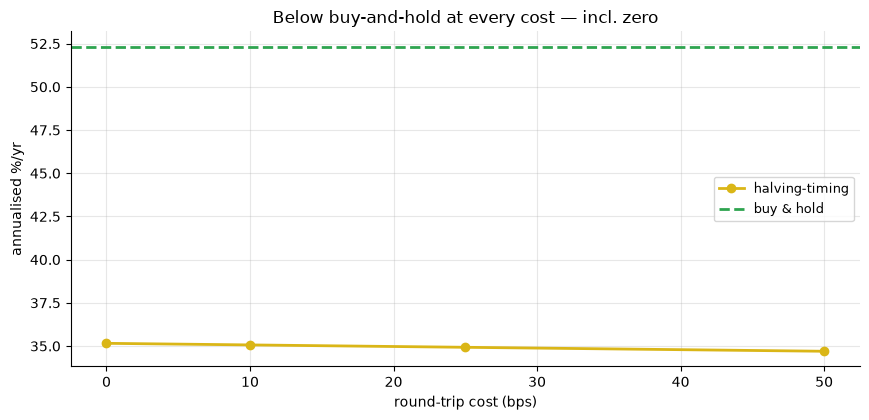

Even gross (0 bps) the timer trails buy-and-hold: the constraint is cash drag, not cost.


In [5]:
if HAVE_REAL:
    cc = [0.0, 10.0, 25.0, 50.0]
    cg = [st.summarize_timing(st.timing_rule(BARS, 0.0, 0.5, cost_bps=c))['cagr_strat']*100 for c in cc]
    bh = st.summarize_timing(st.timing_rule(BARS, 0.0, 0.5))['cagr_bh']*100
else:
    cc = [0,10,25,50]; cg = [36.0,35.1,33.8,31.7]; bh = 52.3
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(cc, cg, 'o-', c=AMBER, lw=2, label='halving-timing')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label='buy & hold')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('annualised %/yr')
ax.set_title('Below buy-and-hold at every cost — incl. zero')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Even gross (0 bps) the timer trails buy-and-hold: the constraint is cash drag, not cost.')

> 💡 In plain words: the timer is below buy-and-hold even at **zero cost**. The binding constraint is the days out of the market, not the trading fee — a tradability **mirage**, not a fragile-but-real edge.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful cycle detector, or does it always print the same number? Plant a halving-locked sinusoid of varying amplitude and read the post-halving bucket's HAC *t*.

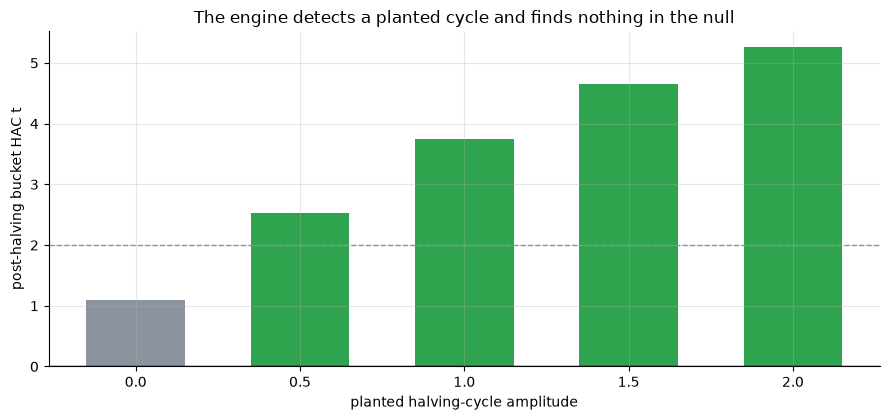

null (amp=0) t=1.09 ; planted (amp=1.5) t=4.65


In [6]:
amps = [0.0, 0.5, 1.0, 1.5, 2.0]
tstats = []
for a in amps:
    b, _ = data.synthetic_daily(n_days=4200, cycle_amp=a, seed=323)
    tstats.append(st.phase_bucket_returns(b, 4).loc[0, 'tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if t >= 2 else GREY for t in tstats]
ax.bar([str(a) for a in amps], tstats, color=col, width=.6)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted halving-cycle amplitude'); ax.set_ylabel('post-halving bucket HAC t')
ax.set_title('The engine detects a planted cycle and finds nothing in the null')
plt.tight_layout(); plt.show()
print('null (amp=0) t=%.2f ; planted (amp=1.5) t=%.2f' % (tstats[0], tstats[3]))

The post-halving bucket's *t* is ~1.1 at the null (amp = 0) and rises to ~4.7 with a planted cycle — so the engine is faithful, and the real-tape bucket-0 number is a statement about *three BTC cycles*, not a machinery artefact. The synthetic Sharpe never backs the Signal stamp.

For the same 'overlay calls the top in hindsight' family, see [Study 117 — Pi-Cycle-Top](../../117-pi-cycle-top/) and [Study 174 — Bitcoin-Rainbow](../../174-bitcoin-rainbow/); for other on-chain 'predicts BTC' theses that also lose to holding, [Study 292 — Bitcoin-Hashrate](../../292-bitcoin-hashrate/).